# **DS Main Project**

---

**Student Name:** Gayathri
**Batch:** DSANB-01
**Project Title:** Cartoon Image generation
**Project Category:**  Basic GAN
**Submission Date:** 25/9/2026

##Stage 1-Data selection , EDA, data cleaning ,data preprocessing



# **DS Main Project**

---

**Student Name:** Gayathri.S

**Batch:** DS ANB 01

**Project Title:** Cartoon Image generation

**Project Category:** Basic GAN

**Submission Date:** 25/09/2026

---


---

## **1. Problem Definition**

### **1.1 Business / Real-World Problem Statement**

Describe the real-world problem being addressed.
Develop an AI-based image-to-image translation system that can automatically transform a real-world photograph into a cartoon-style image while preserving important structural information such as the subject, shape, and overall composition.
---

### **1.2 Project Objectives**

* Understand the real-world problem.
* Analyze and preprocess the dataset.
* Build an appropriate AI model.
* Compare multiple experiments.
* Deploy the final solution.

---

### **1.3 Target Users / Stakeholders**

**Target Users:**
Contact creators, social media users , photographers ,comic creators and Graphic Designers .
---

### **1.4 Input and Expected Output**

**Input:**
Image format: JPG, JPEG, PNG, etc.
Images are resized with 128*128*3 .
Image pixels are normalized from (0 to 255) to (-1 to 1) before giving it into generator.
Paired Images with original and cartoonized portraits during training .

**Expected Output:**
Cartoon-style representation of the same person while retaining the major facial and structural features
---

### **1.5 Proposed AI Solution**

Explain how AI will solve the identified problem.
The proposed GAN-based system is expected to perform effective cartoon-to-cartoon image translation while preserving important structures and features of the input image. The use of paired images provides direct supervision, helping the model learn the specific visual transformation required for the project.
---

### **1.6 Project Category**

* [ ] Deep Learning
* [ ] NLP
* [ ] Transfer Learning
* [*] Basic GAN

**Technique / Model:**
GAN
---
---

## **2. Dataset Selection & Understanding**

### **2.1 Dataset Source**

**Dataset Source:** Insert Source Link
https://huggingface.co/datasets/dqymaggie/cartoonizer-dataset
---

### **2.2 Dataset Description**

* Number of records / samples -5000
* Number of features -2
* Number of classes - unique images
* Dataset purpose - The purpose of the dataset is to provide paired cartoon images for training and evaluating the proposed GAN-based image-to-image translation system
* Data source - Huggingfaces

---

### **2.3 Dataset Overview**

```python
# Shape - (5000,128,128,3)

**Observations:**
*The paired structure of the dataset makes it appropriate for a *conditional GAN (cGAN) approach, as the model can directly *compare the generated cartoon image with its corresponding *target image during training.
---

### **2.5 Target Variable / Class**

**Name:** New Images

**Description:**In the proposed GAN implementation with paired cartoon images, the target variable is the target cartoon image corresponding to each input cartoon image.

**Prediction Goal:** It is a cartoonized portrait that perfectly blends your original photo content with the target cartoon artistic texture

---

## **3. Exploratory Data Analysis**

### **3.1 Import Libraries**

```python


In [1]:
pip install pillow imagehash tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.5 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import tensorflow as tf
import imagehash
from tqdm import tqdm
from PIL import Image
from tensorflow.keras import layers,Model
import os


### **3.2 Load Dataset**

In [3]:
ds = load_dataset("dqymaggie/cartoonizer-dataset",split="train")

README.md:   0%|          | 0.00/468 [00:00<?, ?B/s]

data/train-00000-of-00007-5f5144eeba7d0c(…): reconstructing file:   0%|          |  0.00B /  475MB            

data/train-00000-of-00007-5f5144eeba7d0c(…): downloading bytes:           |  0.00B            

data/train-00001-of-00007-71f5f057e68e92(…): reconstructing file:   0%|          |  0.00B /  473MB            

data/train-00001-of-00007-71f5f057e68e92(…): downloading bytes:           |  0.00B            

...

data/train-00005-of-00007-676034a5f1c6bd(…): reconstructing file:   0%|          |  0.00B /  458MB            

data/train-00005-of-00007-676034a5f1c6bd(…): downloading bytes:           |  0.00B            

data/train-00006-of-00007-549000cd90e9d8(…): reconstructing file:   0%|          |  0.00B /  458MB            

data/train-00006-of-00007-549000cd90e9d8(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/5000 [00:00<?, ? examples/s]

In [4]:
ds=ds.select(range(2000))




## **4. Data Cleaning & Preprocessing**

In [5]:
ds.shape

(2000, 3)

In [6]:
#Data Preprocessing
originalDs=set()
cartoonDs=set()
validIndices=[]
duplicateindices=[]

for idx, item in enumerate(tqdm(ds)):
  try:
    checkValue=False
    originalImage=item["original_image"]
    cartoonImage=item["cartoonized_image"]
    #Image size check
    #If they are not matching , fix the cartoon as per the original image
    if originalImage.size != cartoonImage.size :
    # Resampling using Image.Resampling.LANCZOS preserves sharp cartoon lines
      cartoonImage=cartoonImage.resize(originalImage.size,Image.Resampling.LANCZOS)
      item["cartoonized_image"]=cartoonImage
    #Imagehash acts as the fingerprint of the image and it doesn't only help to find the duplicates but also to measure similarity distance (image similarity)
    orig_hash = imagehash.phash(originalImage)
    cart_hash=imagehash.phash(cartoonImage)
    #Missing value
    if originalImage is None or cartoonImage is None:
      duplicateindices.append(idx)
      continue
    #load looks for the corrupted image .It helps decode the pixel data and if any error is caught , it will throw the error inexcept block
    originalImage.load()
    cartoonImage.load()
  #Duplicate check
    if orig_hash in originalDs or cart_hash in cartoonDs:
      duplicateindices.append(idx)
    else:
     cartoonDs.add(cart_hash)
     originalDs.add(orig_hash)
     validIndices.append(idx)
  except Exception as e:
        # PIL loading errors
        print(f"\n⚠️ Row {idx} is corrupted. Error: {e}")
print("!----Inapproriate values in the cartoon dataset----!",duplicateindices)
if len(duplicateindices) > 0:
  cleandataset=ds.select(validIndices)
else:
  cleandataset=ds




100%|██████████| 2000/2000 [00:56<00:00, 35.12it/s]

!----Inapproriate values in the cartoon dataset----! []


In [7]:
def hf_generator():
    for i in range(len(cleandataset)):
        item = cleandataset[i]
        orig_rgb = item["original_image"].convert("RGB")
        cartoon_rgb = item["cartoonized_image"].convert("RGB")

        # Yield one clean numpy image pair at a time
        yield (
            tf.keras.utils.img_to_array(orig_rgb),
            tf.keras.utils.img_to_array(cartoon_rgb)
        )

# 3. Create the Dataset (expects single items of unknown un-resized shapes)
gan_dataset = tf.data.Dataset.from_generator(
    hf_generator,
    output_signature=(
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32),
        tf.TensorSpec(shape=(None, None, 3), dtype=tf.float32)
    )
)

# 4. Processing function targeting ONE pair at a time
def process_and_normalize(orig_tensor, cartoon_tensor):
    target_size = (128, 128)

    # Resize single tensors safely without shape conflicts
    orig_resized = tf.image.resize(orig_tensor, target_size)
    cartoon_resized = tf.image.resize(cartoon_tensor, target_size)

    # Scale to standard GAN pixel value range [-1, 1]
    orig_norm = (orig_resized / 127.5) - 1.0
    cartoon_norm = (cartoon_resized / 127.5) - 1.0

    return orig_norm, cartoon_norm

# 5. Map the resizing first (Processes single elements in parallel)
gan_dataset = gan_dataset.map(process_and_normalize, num_parallel_calls=tf.data.AUTOTUNE)

#prefetching prepares future batches in the background while the GPU trains the current batch.
# Images are now all uniformly (128, 128, 3), so batching will never crash!
gan_dataset = gan_dataset.shuffle(buffer_size=500).batch(32).prefetch(tf.data.AUTOTUNE)

In [8]:

for orig_batch, cartoon_batch in gan_dataset.take(1):
    print("--- Safe Pipeline Check Passed ---")
    print(f"Batch Shape: {orig_batch.shape} (Perfect uniform dimensions!)")
    print(f"Original Range: [{tf.reduce_min(orig_batch).numpy():.4f} to {tf.reduce_max(orig_batch).numpy():.4f}]")
    print(f"Cartoon Range:  [{tf.reduce_min(cartoon_batch).numpy():.4f} to {tf.reduce_max(cartoon_batch).numpy():.4f}]")

--- Safe Pipeline Check Passed ---
Batch Shape: (32, 128, 128, 3) (Perfect uniform dimensions!)
Original Range: [-1.0000 to 1.0000]
Cartoon Range:  [-1.0000 to 1.0000]


In [10]:
print(tf.__version__)
print(tf.config.list_physical_devices('GPU'))

2.20.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


### **3.7 Visualizations**


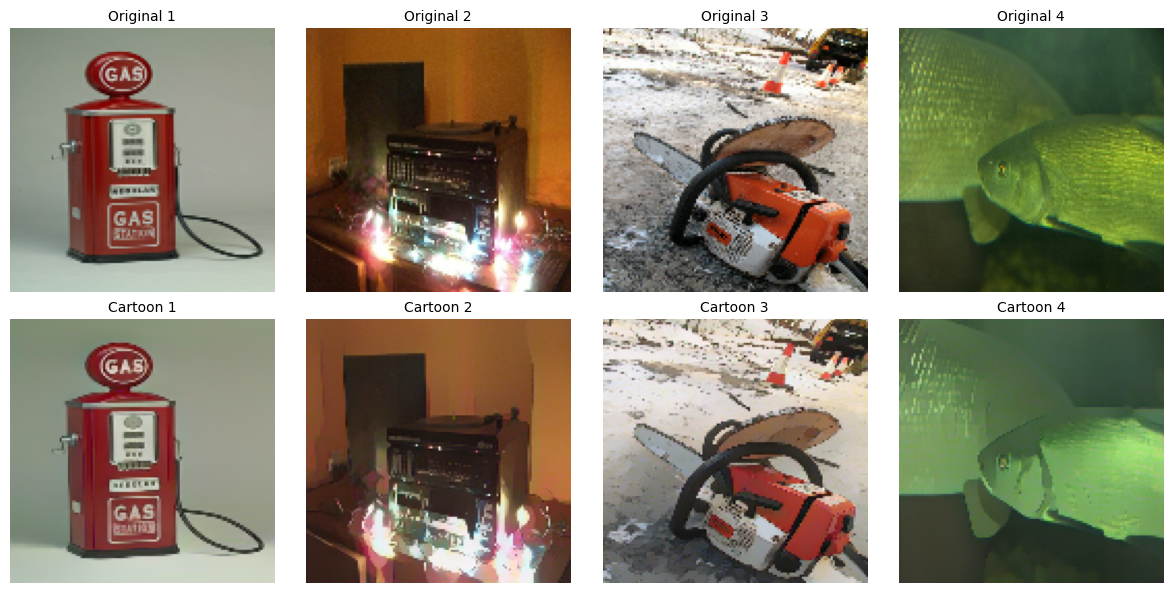

In [12]:
num_pairs_to_show = 4  # Number of pairs you want to display side-by-side
for orig_batch, cartoon_batch in gan_dataset.take(1):

    # Create a grid: 2 rows (Original on Top, Cartoon on Bottom)
    fig, axes = plt.subplots(2, num_pairs_to_show, figsize=(3 * num_pairs_to_show, 6))

    for i in range(num_pairs_to_show):
        # 2. Denormalize images from [-1, 1] back to [0, 1] for Matplotlib
        orig_img = (orig_batch[i].numpy() + 1.0) / 2.0
        cartoon_img = (cartoon_batch[i].numpy() + 1.0) / 2.0

        # 3. Plot Original Image (Top Row)
        ax_orig = axes[0, i] if num_pairs_to_show > 1 else axes[0]
        ax_orig.imshow(orig_img)
        ax_orig.set_title(f"Original {i+1}", fontsize=10)
        ax_orig.axis("off")

        # 4. Plot Corresponding Cartoon Image (Bottom Row)
        ax_cartoon = axes[1, i] if num_pairs_to_show > 1 else axes[1]
        ax_cartoon.imshow(cartoon_img)
        ax_cartoon.set_title(f"Cartoon {i+1}", fontsize=10)
        ax_cartoon.axis("off")

    plt.tight_layout()
    plt.show()

In [13]:
def resnet_block(input_tensor,filters):
  x = layers.Conv2D(filters, kernel_size=3, padding="same")(input_tensor)
  x = layers.BatchNormalization()(x)
  x = layers.ReLU()(x)

  x = layers.Conv2D(filters, kernel_size=3, padding="same")(x)
  x = layers.BatchNormalization()(x)
  return layers.add([input_tensor, x])


In [14]:
def build_generator(img_shape=(128,128,3)):
  #Translates original images into cartoonized portraits
    inputs = layers.Input(shape=img_shape, name="photo_input")
    #Conv2D helps to extract spatial features such as edges,textures,shapes,corners from  grid data images from sliding learnable features across the input data
    #Encoder
    x=layers.Conv2D(32,kernel_size=7,padding="same",activation="relu")(inputs)
    x=layers.Conv2D(64,kernel_size=3,padding="same",strides=2,activation="relu")(x)
    x=layers.Conv2D(128,kernel_size=3,padding="same",strides=2,activation="relu")(x)
    #Resnet blocks used to solve the vanishing gradient problem when its shrinks the image
    for _ in range(6):
      x = resnet_block(x, 128)
     # Decoder
    x = layers.Conv2DTranspose(64, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    x = layers.Conv2DTranspose(32, kernel_size=3, strides=2, padding="same", activation="relu")(x)
    outputs = layers.Conv2D(3, kernel_size=7, padding="same", activation="tanh")(x)

    return Model(inputs, outputs, name="Generator")




In [15]:
def build_discriminator_extractor(img_shape=(128, 128, 3)):
    #Extracts features from scratch and classifies real vs fake patches.
    original = layers.Input(shape=img_shape, name="original_image")
    cartoon_image=layers.Input(shape=img_shape, name="cartoon_image")
    x=layers.concatenate([original,cartoon_image],axis=-1)

    #Low Level feature mapping to capture Layer 1: Low-Level Features (Edges, Gradients, Lines)
    x = layers.Conv2D(32, kernel_size=4, strides=2, padding="same")(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    #Mid level Geometric shapes and corners,curves Layer 2: Mid-Level Features (Geometric Shapes, Contours, Intersections)
    x = layers.Conv2D(64, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)

    # TARGET LAYER FOR FEATURE EXTRACTION (Shape: 32, 32, 128) High level semantic features like eyes , noses
    x = layers.Conv2D(128, kernel_size=4, strides=2, padding="same")(x)
    x = layers.BatchNormalization()(x)
    extracted_features = layers.LeakyReLU(negative_slope=0.2, name="features")(x)

    # PatchGAN Classification Output
    classification_out = layers.Conv2D(1, kernel_size=4, strides=1, padding="same", activation="sigmoid")(extracted_features)

    return Model(inputs=[original,cartoon_image], outputs=[classification_out, extracted_features], name="Discriminator_Extractor")


In [16]:
generator=build_generator()
discriminator=build_discriminator_extractor()

In [17]:
generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

# Loss Functions
cross_entropy = tf.keras.losses.BinaryCrossentropy()


In [18]:
def calculate_diversity_metric(discriminator_features):
#Higher values mean the model is generating diverse, rich textures.
    batch_mean, batch_variance = tf.nn.moments(discriminator_features, axes=[0])
    return tf.reduce_mean(batch_variance)





In [35]:
@tf.function
def train_step_function(generator,discriminator,original_image,cartoon_image,ssim_weight=5):

  #executes single forward/backward pass
  #GradientTape helps to track the record when its a forward pass every single operation which happens
  # to its data through the weights and calculate loss score after creating the final image
      with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        #This helps to generate the cartoon image using generator model
        cartoon_new = generator(original_image,training=True)
       # print("Original",cartoon_image.shape)
        #print("generated one",cartoon_new.shape)

        real_disc_op,original_features = discriminator([original_image,cartoon_image],training=True)
        generated_disc_op,fake_features = discriminator([original_image,cartoon_new],training=True)

        gen_loss=cross_entropy(tf.ones_like(generated_disc_op),generated_disc_op)
        real_loss=cross_entropy(tf.ones_like(real_disc_op),real_disc_op)
        generated_loss=cross_entropy(tf.zeros_like(generated_disc_op),generated_disc_op)
        disc_loss=real_loss+generated_loss
        ssi = tf.image.ssim(cartoon_image,cartoon_new,max_val=2.0)
        avg_ssim=tf.reduce_mean(ssi)

       # Invert the metric into a mismatch penalty loss
        mismatch_loss = tf.reduce_mean(1.0 - ssi)

        total_gen_loss=gen_loss+ssim_weight*mismatch_loss


      #calculate gradients
      gen_gradient=gen_tape.gradient(total_gen_loss,generator.trainable_variables)
      disc_gradient = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

      # Apply gradients (Backpropagation)
      generator_optimizer.apply_gradients(zip(gen_gradient,generator.trainable_variables))
      discriminator_optimizer.apply_gradients(zip(disc_gradient,discriminator.trainable_variables))
      # Calculate structural similarity index per image in the batch

        #Image Quality loss
      img_quality_ssi=tf.image.ssim(original_image,cartoon_new,max_val=2.0)
      img_quality_loss=tf.reduce_mean(1.0 - img_quality_ssi)

      #Image diversity
      img_diversity=calculate_diversity_metric(fake_features)


      return total_gen_loss, disc_loss, mismatch_loss,img_quality_loss,img_diversity





In [36]:
def save_training_stage_comparison(epoch, photo_batch, target_batch, generator, save_dir="training_stages"):
    """
    Saves a clean side-by-side comparison grid of the 3 stages:
    Original Photo | Actual Cartoon | Generated Cartoon
    """
    os.makedirs(save_dir, exist_ok=True)

    # 1. Generate the cartoon using inference mode (training=False)
    generated_batch = generator(photo_batch, training=False)

    # 2. Denormalize images from [-1, 1] back to [0, 1] for matplotlib display
    photos = (photo_batch + 1.0) / 2.0
    targets = (target_batch + 1.0) / 2.0
    generated = (generated_batch + 1.0) / 2.0



    # We will plot the first 3 images from the batch as a representative sample
    num_samples = min(3, photo_batch.shape[0])

    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))

    # Handle single-sample layout indexing quirks in matplotlib
    if num_samples == 1:
        axes = [axes]

    for i in range(num_samples):
        # Column 1: Input Photo
        axes[i][0].imshow(photos[i])
        axes[i][0].axis('off')
        if i == 0: axes[i][0].set_title("Input Photo", fontsize=14, fontweight='bold')

        # Column 2: Actual Target Cartoon
        axes[i][1].imshow(targets[i])
        axes[i][1].axis('off')
        if i == 0: axes[i][1].set_title("Actual Cartoon (GT)", fontsize=14, fontweight='bold')

        # Column 3: Generated Output
        axes[i][2].imshow(generated[i])
        axes[i][2].axis('off')
        if i == 0: axes[i][2].set_title("Generated Cartoon", fontsize=14, fontweight='bold')


    plt.tight_layout()
    save_path = os.path.join(save_dir, f"stage_epoch_{epoch}.png")
    plt.savefig(save_path, bbox_inches='tight', dpi=150)
    plt.close()
    print(f"🖼️ Visual stage comparison saved successfully to: {save_path}")

In [37]:
EPOCHS = 15

print("!-- Initiating functional Cartoon GAN training loop...")
epoch_gen_loss_list=[]
epoch_disc_loss_list=[]
epoch_ssim_list=[]
epoch_img_quality_list=[]
epoch_img_diversity_list=[]
for epoch in range(EPOCHS):
    print(f"\n--- Epoch {epoch + 1}/{EPOCHS} ---")

    # Track metrics manually for console printouts
    epoch_gen_loss = 0.0 #Total generator Loss
    epoch_disc_loss = 0.0#Total discriminator Loss
    epoch_ssim = 0.0#Image Mismatch
    epoch_img_quality=0.0
    epoch_img_diversity=0.0
    steps = 0

    for step, (photo_batch, target_cartoon_batch) in enumerate(gan_dataset):
        # Call the standalone training step function
        g_loss, d_loss, ssim,img_quality,img_diversity = train_step_function(
             generator, discriminator,photo_batch, target_cartoon_batch
        )

        # Accumulate metrics
        epoch_gen_loss += g_loss.numpy()
        epoch_disc_loss += d_loss.numpy()
        epoch_ssim += ssim.numpy()
        epoch_img_quality += img_quality.numpy()
        epoch_img_diversity += img_diversity.numpy()
        steps += 1
        print(step)
        # Print real-time updates every 50 batches
        if step % 50 == 0:
            print(f"  Step {step} | Gen Loss: {g_loss.numpy():.4f} | Disc Loss: {d_loss.numpy():.4f} | Batch SSIM: {ssim.numpy():.4f} | Image Quality : {img_quality.numpy()} | Image Diversity :{img_diversity.numpy()}")
        if step==62:
          save_training_stage_comparison(epoch=epoch + 1, photo_batch=photo_batch, target_batch=target_cartoon_batch,  generator=generator)

    # Calculate and print epoch summary
    print(f" Epoch Final Summary -> Avg Gen Loss: {epoch_gen_loss/steps:.4f} | Avg SSIM: {epoch_ssim/steps:.4f} | Avg Discriminator Loss :{epoch_disc_loss/steps:.4f} | Avg img Quality :{epoch_img_quality/steps:.4f} | Avg Img Diversity :{epoch_img_diversity/steps:.4f}")
    epoch_gen_loss_list.append(epoch_gen_loss/steps)
    epoch_disc_loss_list.append(epoch_disc_loss/steps)
    epoch_ssim_list.append(epoch_ssim/steps)
    epoch_img_quality_list.append(epoch_img_quality/steps)
    epoch_img_diversity_list.append(epoch_img_diversity/steps)

!-- Initiating functional Cartoon GAN training loop...

--- Epoch 1/15 ---
0
  Step 0 | Gen Loss: 2.9373 | Disc Loss: 1.2369 | Batch SSIM: 0.4179 | Image Quality : 0.4196641743183136 | Image Diversity :0.3394237160682678
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
  Step 50 | Gen Loss: 2.9879 | Disc Loss: 1.3200 | Batch SSIM: 0.4427 | Image Quality : 0.48017632961273193 | Image Diversity :0.3439921736717224
51
52
53
54
55
56
57
58
59
60
61
62
🖼️ Visual stage comparison saved successfully to: training_stages/stage_epoch_1.png
 Epoch Final Summary -> Avg Gen Loss: 2.9073 | Avg SSIM: 0.4338 | Avg Discriminator Loss :1.3795 | Avg img Quality :0.4772 | Avg Img Diversity :0.3468

--- Epoch 2/15 ---
0
  Step 0 | Gen Loss: 2.9693 | Disc Loss: 1.3941 | Batch SSIM: 0.4475 | Image Quality : 0.5094016790390015 | Image Diversity :0.34034213423728943
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21


Observation:

SSIM Metric-> Structural Similarity Index (SSIM)
This helps us to find the similarity check . It focuses  purely on structural attributes like overall lighting , sharpness of lights and edges . cartoon image alter the pixel color values from  the real photo .while comparing both real and cartoon images, SSIM considers the outlines, shapes, and structural boundaries of the subject and it align spatially ignoring  the colors.

Image Diversity->This tells us exactly how generated image looks different from one another within a batch and also it checks the model work in the intermediate layers.Basically , it checks the colors,textures and brushstrokes which has to be vary from image to image using the metric and if the image looks different from  one to another image then it holds higher variance (this is really creative and also in the correct path) but if the image looks same , then it just does the copy paste job with zero variance (Mode Collapse scenario). This will make the generator lazy because while i pass the image to generator , it generates the cartoon portrait and the discriminator gives the result as 100% Real. then The Generator continue to work with the same look again and again which make the discriminator tricks to be real , as it got passed in first image. This makes the generator to continues with the copy paste job  

Final Analysis:
Image Diversity
This is a very healthy scores. Because it is well above zero, my Generator is producing a wide, creative variety of cartoon textures and colors across the batch instead of copy-pasting.

My g_loss is right around 0.69, which is the exact mathematical center point  for a Binary Crossentropy loss when a generator is perfectly competitive. The Discriminator is slightly winning the tug-of-war, which is normal for early steps as the Critic sets up the boundaries for line art and style.Maybe increasing epoches for about 10 might increase the generator loss too.

Batch SSIM (0.5044) ➔ Perfect: my generated cartoon has successfully hit the exact structural sweet spot of real human animation. It has discarded the messy photo details while locking  the core spatial composition as its compared with real and target cartoon images but target cartoon images flatten out those textures completely replacing them with big blocks of solid ink, stylized face proportions and sharp black brush outlines.So Scoring 50% , its great .

Image Quality->Image Quality talks about the quality of the image compared original and newly created cartoon images which also maintains the good score.

In [22]:
epoch_disc_loss_list

[np.float32(1.4597392),
 np.float32(1.4228163),
 np.float32(1.4066273),
 np.float32(1.3991096),
 np.float32(1.3951933),
 np.float32(1.393053),
 np.float32(1.3918625),
 np.float32(1.390816),
 np.float32(1.389928),
 np.float32(1.3894278),
 np.float32(1.3893042),
 np.float32(1.3889247),
 np.float32(1.3884068),
 np.float32(1.3884764),
 np.float32(1.3882614),
 np.float32(1.3880504),
 np.float32(1.3877605),
 np.float32(1.3878323),
 np.float32(1.3875462),
 np.float32(1.3880763)]

In [23]:
epoch=len(epoch_gen_loss_list)

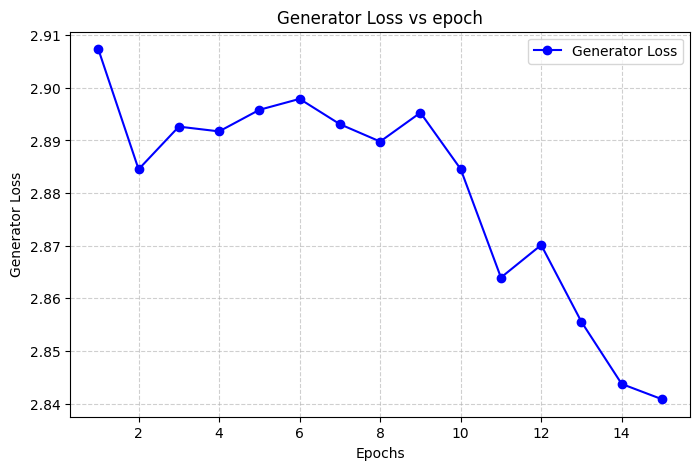

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,len(epoch_gen_loss_list)+1), epoch_gen_loss_list, label='Generator Loss', color='blue', marker='o')

# Formatting
plt.title('Generator Loss vs epoch')
plt.xlabel('Epochs')
plt.ylabel('Generator Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the chart
plt.show()


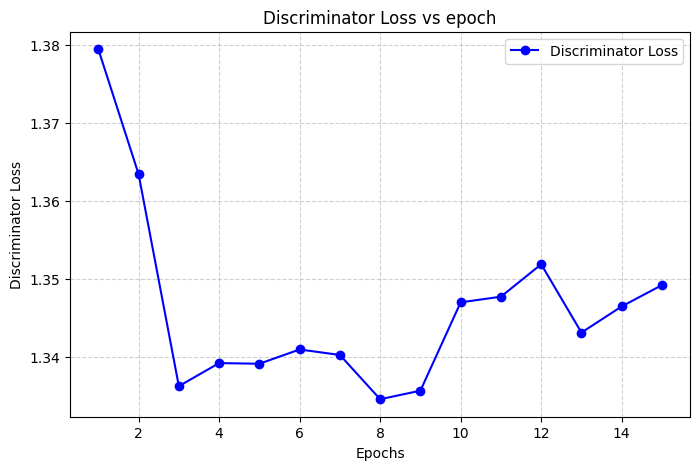

In [39]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,len(epoch_disc_loss_list)+1), epoch_disc_loss_list, label='Discriminator Loss', color='blue', marker='o')

# Formatting
plt.title('Discriminator Loss vs epoch')
plt.xlabel('Epochs')
plt.ylabel('Discriminator Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the chart
plt.show()


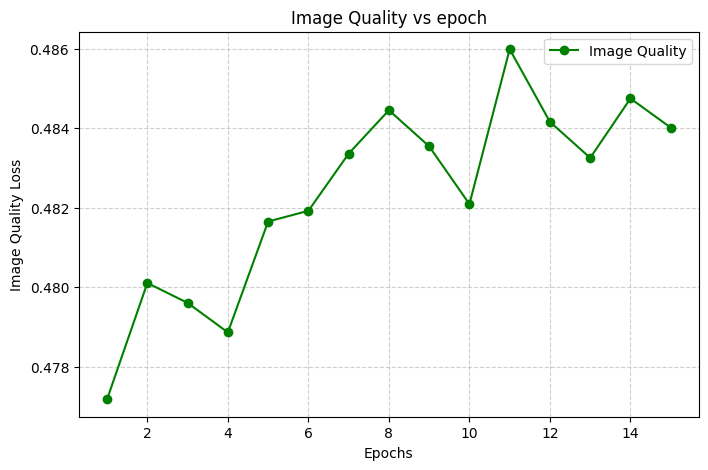

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,len(epoch_img_quality_list)+1), epoch_img_quality_list, label='Image Quality', color='Green', marker='o')

# Formatting
plt.title('Image Quality vs epoch')
plt.xlabel('Epochs')
plt.ylabel('Image Quality Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the chart
plt.show()


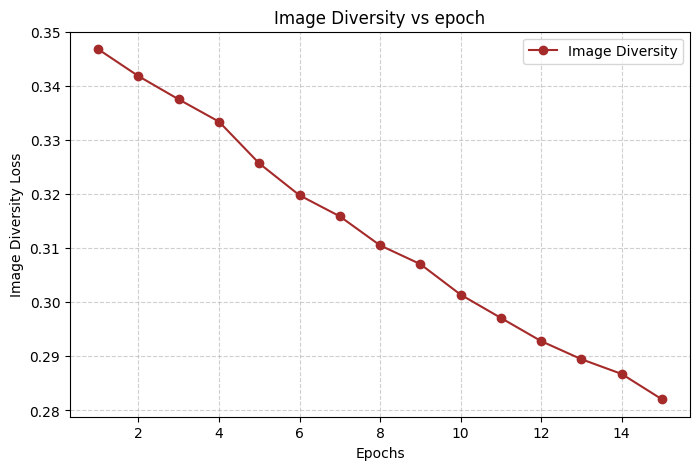

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(range(1,len(epoch_img_diversity_list)+1), epoch_img_diversity_list, label='Image Diversity', color='brown', marker='o')

# Formatting
plt.title('Image Diversity vs epoch')
plt.xlabel('Epochs')
plt.ylabel('Image Diversity Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Display the chart
plt.show()
